✅ All results loaded!


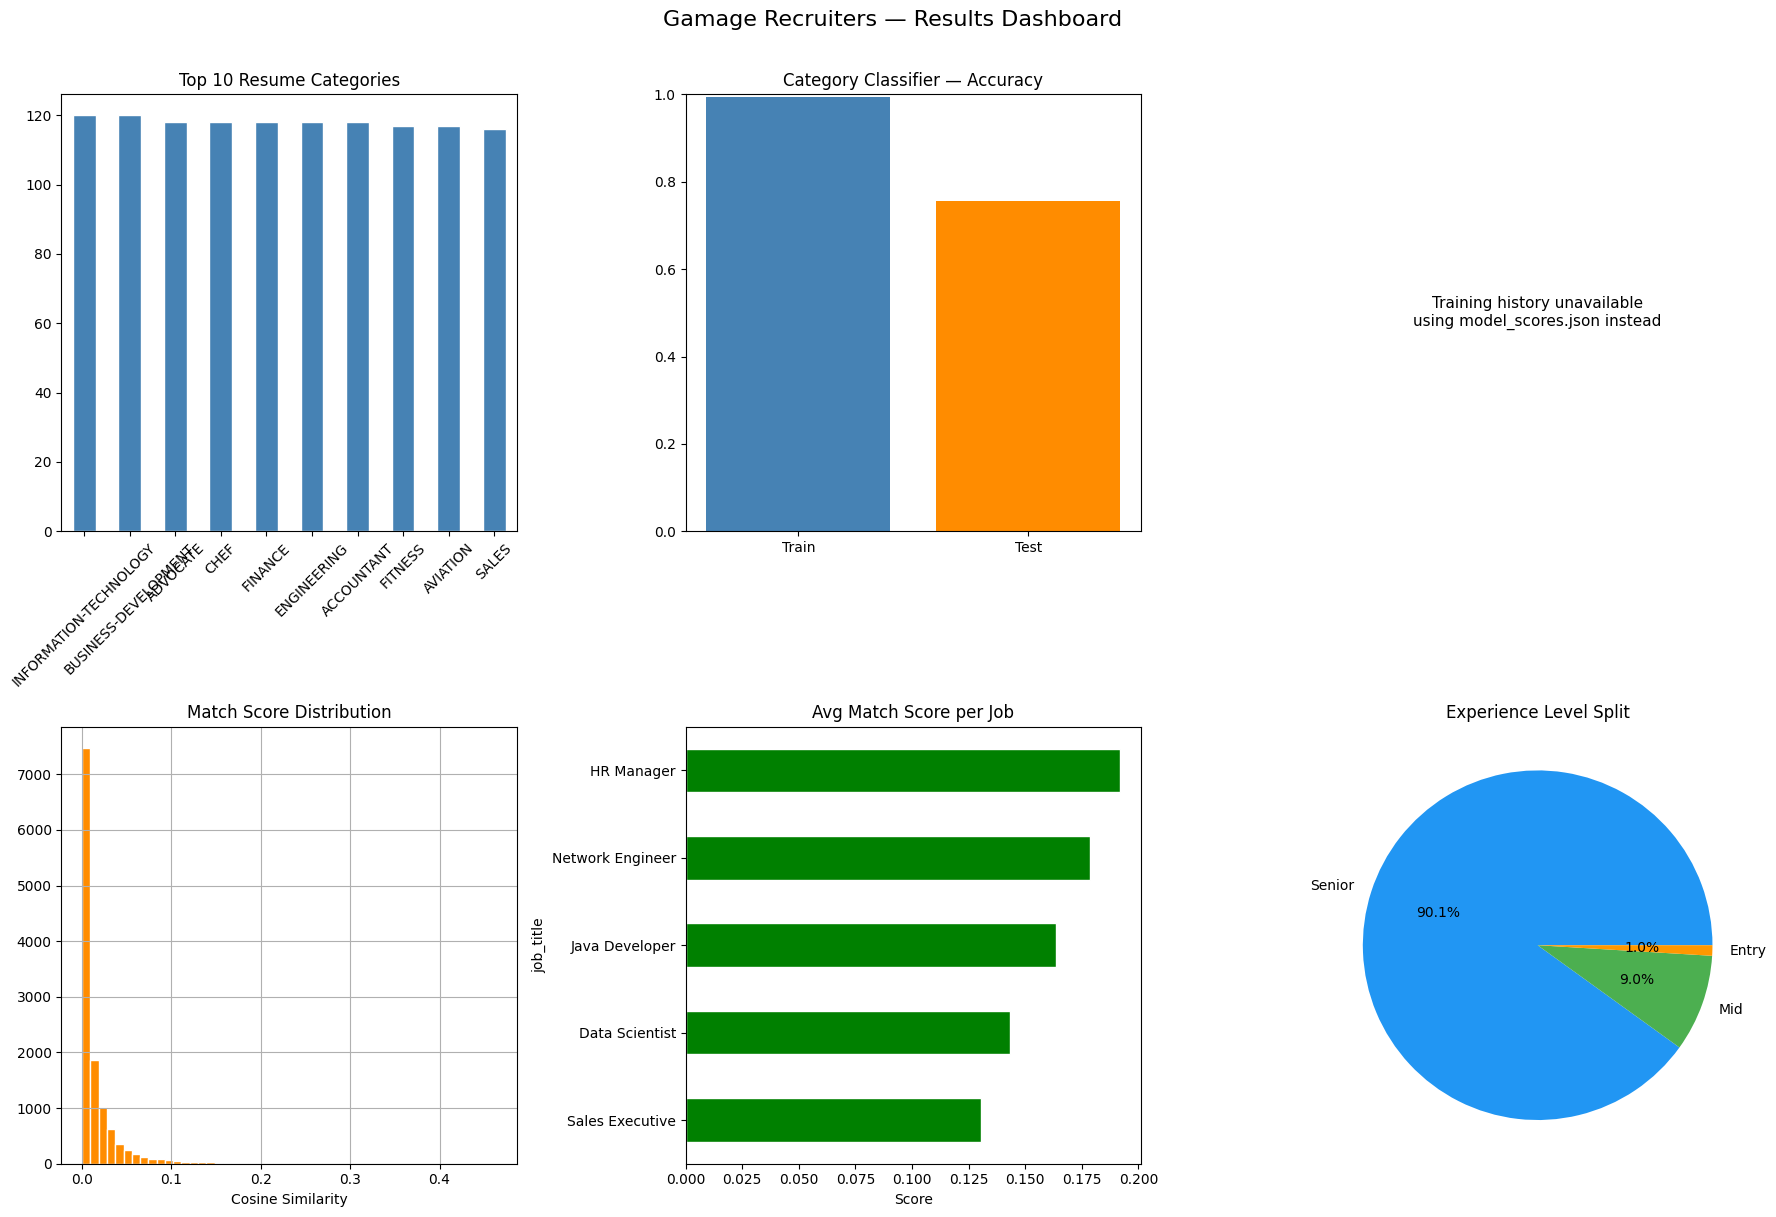

✅ Dashboard saved → results/plots/results_dashboard.png
        FINAL SUMMARY — GAMAGE RECRUITERS

📁 Dataset
   Total resumes    : 2484
   Job categories   : 24

🧹 Preprocessing
   Method           : HTML strip, lowercase, stopword removal
   Vectorization    : TF-IDF (5000 features, unigrams + bigrams)

🧠 Classification
   Best Val Accuracy: 75.65%
   Models saved     : best_category_classifier.keras
                      best_exp_classifier.keras

🎯 Matching
   Total matches    : 12420
   Filtered matches : 322 (score > 0.1)

🔑 Keyword Extraction
   Method           : TF-IDF feature scores per category

💡 Suggestions
   1. Use Word2Vec or GloVe embeddings
   2. Try LSTM or BERT for better accuracy
   3. Add more job description variety for matching

✅ Project complete!


In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, os
from sklearn.metrics import accuracy_score

os.makedirs("../results/plots", exist_ok=True)

# ── Cell 2: Load all results ──────────────────────────────────────────────────
df           = pd.read_csv("../data/resume_dataset.csv")
all_matches  = pd.read_csv("../results/metrics/all_matches.csv")
filtered     = pd.read_csv("../results/metrics/filtered_matches.csv")

history_path = "../results/metrics/cat_history.json"
scores_path  = "../results/metrics/model_scores.json"
cat_history  = None
model_scores  = {}

if os.path.exists(history_path):
    with open(history_path) as f:
        cat_history = json.load(f)
elif os.path.exists(scores_path):
    with open(scores_path) as f:
        model_scores = json.load(f)

with open("../results/metrics/category_classification_report.txt") as f:
    cat_report = f.read()

print("✅ All results loaded!")

# ── Cell 3: Results dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# Plot 1: Category distribution
ax1 = fig.add_subplot(gs[0, 0])
df['Category'].value_counts().head(10).plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Top 10 Resume Categories')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Training accuracy
ax2 = fig.add_subplot(gs[0, 1])
if cat_history is not None:
    ax2.plot(cat_history['accuracy'],     label='Train')
    ax2.plot(cat_history['val_accuracy'], label='Validation')
    ax2.set_title('Category Classifier — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
else:
    ax2.bar(['Train', 'Test'], [model_scores.get('category_train', np.nan), model_scores.get('category_test', np.nan)], color=['steelblue', 'darkorange'])
    ax2.set_title('Category Classifier — Accuracy')
    ax2.set_ylim(0, 1)

# Plot 3: Training loss
ax3 = fig.add_subplot(gs[0, 2])
if cat_history is not None:
    ax3.plot(cat_history['loss'],     label='Train')
    ax3.plot(cat_history['val_loss'], label='Validation')
    ax3.set_title('Category Classifier — Loss')
    ax3.set_xlabel('Epoch')
    ax3.legend()
else:
    ax3.axis('off')
    ax3.text(0.5, 0.5, 'Training history unavailable\nusing model_scores.json instead', ha='center', va='center', fontsize=11)

# Plot 4: Match score distribution
ax4 = fig.add_subplot(gs[1, 0])
all_matches['match_score'].hist(bins=50, ax=ax4, color='darkorange', edgecolor='white')
ax4.set_title('Match Score Distribution')
ax4.set_xlabel('Cosine Similarity')

# Plot 5: Top matched jobs
ax5 = fig.add_subplot(gs[1, 1])
filtered.groupby('job_title')['match_score'].mean().sort_values().plot(
    kind='barh', ax=ax5, color='green', edgecolor='white')
ax5.set_title('Avg Match Score per Job')
ax5.set_xlabel('Score')

# Plot 6: Experience distribution
ax6 = fig.add_subplot(gs[1, 2])
df['experience_level'].value_counts().plot(
    kind='pie', ax=ax6, autopct='%1.1f%%',
    colors=['#2196F3','#4CAF50','#FF9800'])
ax6.set_title('Experience Level Split')
ax6.set_ylabel('')

plt.suptitle('Gamage Recruiters — Results Dashboard', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("../results/plots/results_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved → results/plots/results_dashboard.png")

# ── Cell 4: Print final summary ───────────────────────────────────────────────
best_acc = max(cat_history['val_accuracy']) if cat_history is not None else model_scores.get('category_test', np.nan)

print("=" * 60)
print("        FINAL SUMMARY — GAMAGE RECRUITERS")
print("=" * 60)
print(f"\n📁 Dataset")
print(f"   Total resumes    : {len(df)}")
print(f"   Job categories   : {df['Category'].nunique()}")
print(f"\n🧹 Preprocessing")
print(f"   Method           : HTML strip, lowercase, stopword removal")
print(f"   Vectorization    : TF-IDF (5000 features, unigrams + bigrams)")
print(f"\n🧠 Classification")
print(f"   Best Val Accuracy: {best_acc:.2%}")
print(f"   Models saved     : best_category_classifier.keras")
print(f"                      best_exp_classifier.keras")
print(f"\n🎯 Matching")
print(f"   Total matches    : {len(all_matches)}")
print(f"   Filtered matches : {len(filtered)} (score > 0.1)")
print(f"\n🔑 Keyword Extraction")
print(f"   Method           : TF-IDF feature scores per category")
print(f"\n💡 Suggestions")
print(f"   1. Use Word2Vec or GloVe embeddings")
print(f"   2. Try LSTM or BERT for better accuracy")
print(f"   3. Add more job description variety for matching")
print("\n" + "=" * 60)
print("✅ Project complete!")
print("=" * 60)